# Model Building — Parkinson's UPDRS Prediction

**Bài toán:** Multi-output Regression — predict đồng thời `motor_UPDRS` và `total_UPDRS`

**Pipeline:**
1. Load dữ liệu đã preprocessed (từ notebook EDA)
2. Baseline: Ridge / Lasso
3. SVR
4. Random Forest
5. Gradient Boosting (XGBoost)
6. MLP (Neural Network)
7. So sánh tổng hợp + Feature Importance
8. Predict trên test set với model tốt nhất

In [1]:
!pip install ucimlrepo


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\23521\miniconda3\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, time, pickle

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GroupKFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy.stats import randint, uniform
import xgboost as xgb
from sklearn.metrics import mean_absolute_percentage_error
from scipy.stats import pearsonr

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11})
PALETTE = sns.color_palette("muted")
SEED = 42
print("Imports OK")

Imports OK


In [3]:
data = pd.read_csv("preprocessed_data.csv")
data.head()

,Unnamed: 0,age,test_time,NHR,HNR,RPDE,DFA,PPE,motor_UPDRS,total_UPDRS,Jitter(avg),Shimmer(avg)
0,0,72,5.6431,0.0143,21.6400,0.4189,0.5484,0.1601,28.1990,34.3980,0.0052,0.0571
1,1,72,12.6660,0.0111,27.1830,0.4349,0.5648,0.1081,28.4470,34.8940,0.0020,0.0444
2,2,72,19.6810,0.0202,23.0470,0.4622,0.5441,0.2101,28.6950,35.3890,0.0030,0.0417
3,3,72,25.6470,0.0278,24.4450,0.4873,0.5779,0.3328,28.9050,35.8100,0.0031,0.0711
4,4,72,33.6420,0.0116,26.1260,0.4719,0.5612,0.1936,29.1870,36.3750,0.0017,0.0413


## 1. Load dữ liệu đã preprocessed

In [24]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import RobustScaler
import numpy as np

# Load data
data = pd.read_csv("preprocessed_data.csv")
data = data.rename(columns={'Unnamed: 0': 'subject#', 'Jitter(avg)': 'Jitter_avg', 'Shimmer(avg)': 'Shimmer_avg'})

TARGET = ['motor_UPDRS', 'total_UPDRS']
features = [col for col in data.columns if col not in TARGET + ['subject#']]

X = data[features]
y = data[TARGET]

# Split theo subject để tránh data leakage
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups=data['subject#']))

X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# --- BƯỚC SCALING ---
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=features)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=features)

train_subjects = data.iloc[train_idx]['subject#'].values

print(f"X_train scaled: {X_train.shape} | X_test scaled: {X_test.shape}")
print(f"Features đã chuẩn hóa: {list(X_train.columns)}")

X_train scaled: (4700, 9) | X_test scaled: (1175, 9)
Features đã chuẩn hóa: ['age', 'test_time', 'NHR', 'HNR', 'RPDE', 'DFA', 'PPE', 'Jitter_avg', 'Shimmer_avg']


## 2. Helper functions

In [5]:
TARGETS = ['motor_UPDRS', 'total_UPDRS']

def evaluate(y_true, y_pred, split='Test'):
    """Tính RMSE, MAE, R² cho cả 2 targets."""
    results = {}
    for i, col in enumerate(TARGETS):
        yt = y_true.iloc[:, i] if hasattr(y_true, 'iloc') else y_true[:, i]
        yp = y_pred[:, i] if y_pred.ndim == 2 else y_pred
        rmse = np.sqrt(mean_squared_error(yt, yp))
        mae  = mean_absolute_error(yt, yp)
        r2   = r2_score(yt, yp)
        mape = mean_absolute_percentage_error(yt, yp)
        corr, _ = pearsonr(yt, yp)
        results[col] = {'RMSE': rmse, 'MAE': mae, 'R²': r2, 'MAPE': mape, 'Pearson_r': corr}
    df_res = pd.DataFrame(results).T
    print(f"\n── {split} Set ──")
    print(df_res.round(4))
    return df_res

def cv_score(model, X, y, groups, n_splits=5, label=''):
    """GroupKFold cross-validation — trả về mean RMSE và R²."""
    gkf = GroupKFold(n_splits=n_splits)
    rmse_motor, rmse_total, r2_motor, r2_total = [], [], [], []
    for train_i, val_i in gkf.split(X, y, groups):
        Xtr, Xval = X[train_i], X[val_i]
        ytr, yval = y[train_i], y[val_i]
        model.fit(Xtr, ytr)
        pred = model.predict(Xval)
        rmse_motor.append(np.sqrt(mean_squared_error(yval[:, 0], pred[:, 0])))
        rmse_total.append(np.sqrt(mean_squared_error(yval[:, 1], pred[:, 1])))
        r2_motor.append(r2_score(yval[:, 0], pred[:, 0]))
        r2_total.append(r2_score(yval[:, 1], pred[:, 1]))
    print(f"\n{'='*50}")
    print(f"[{label}] GroupKFold CV ({n_splits} folds)")
    print(f"  motor_UPDRS  — RMSE: {np.mean(rmse_motor):.4f} ± {np.std(rmse_motor):.4f}  |  R²: {np.mean(r2_motor):.4f}")
    print(f"  total_UPDRS  — RMSE: {np.mean(rmse_total):.4f} ± {np.std(rmse_total):.4f}  |  R²: {np.mean(r2_total):.4f}")
    return {
        'motor_RMSE': np.mean(rmse_motor), 'total_RMSE': np.mean(rmse_total),
        'motor_R2':   np.mean(r2_motor),   'total_R2':   np.mean(r2_total)
    }

X_tr_arr = X_train.values
y_tr_arr = y_train.values

# summary dict để collect kết quả
cv_results  = {}
test_results = {}
print("Helpers ready.")

Helpers ready.


## 3. Baseline: Ridge & Lasso

Ridge dùng L2 regularization — phù hợp khi có multicollinearity.  
Lasso dùng L1 — có thể zero-out một số features, hữu ích để kiểm tra feature importance.

In [6]:
from sklearn.linear_model import Ridge, RidgeCV

# 1. Baseline Ridge
ridge_base = MultiOutputRegressor(Ridge(alpha=1.0), n_jobs=-1)
cv_results['Ridge_Baseline'] = cv_score(ridge_base, X_tr_arr, y_tr_arr, train_subjects, label='Ridge Baseline')
ridge_base.fit(X_tr_arr, y_tr_arr)
test_results['Ridge_Baseline'] = evaluate(y_test, ridge_base.predict(X_test.values), 'Ridge Baseline')

# 2. Tuned Ridge
ridge_cv = MultiOutputRegressor(RidgeCV(alphas=np.logspace(-3, 3, 10)), n_jobs=-1)
cv_results['Ridge_Tuned'] = cv_score(ridge_cv, X_tr_arr, y_tr_arr, train_subjects, label='Ridge Tuned')
ridge_cv.fit(X_tr_arr, y_tr_arr)
test_results['Ridge_Tuned'] = evaluate(y_test, ridge_cv.predict(X_test.values), 'Ridge Tuned')


[Ridge Baseline] GroupKFold CV (5 folds)
  motor_UPDRS  — RMSE: 7.5726 ± 0.0381  |  R²: 0.1393
  total_UPDRS  — RMSE: 9.8448 ± 0.0510  |  R²: 0.1599

── Ridge Baseline Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 7.5688 6.4412 0.1025 0.3902     0.3266
total_UPDRS 9.7620 8.1516 0.1400 0.3507     0.3771

[Ridge Tuned] GroupKFold CV (5 folds)
  motor_UPDRS  — RMSE: 7.5726 ± 0.0375  |  R²: 0.1393
  total_UPDRS  — RMSE: 9.8447 ± 0.0502  |  R²: 0.1599

── Ridge Tuned Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 7.5672 6.4414 0.1029 0.3903     0.3267
total_UPDRS 9.7604 8.1508 0.1403 0.3508     0.3772


In [7]:
from sklearn.linear_model import LassoCV
lasso_cv_motor = LassoCV(cv=5, random_state=SEED).fit(X_tr_arr, y_tr_arr[:, 0])
lasso_cv_total = LassoCV(cv=5, random_state=SEED).fit(X_tr_arr, y_tr_arr[:, 1])
print(f"Best alpha — motor: {lasso_cv_motor.alpha_:.4f}  |  total: {lasso_cv_total.alpha_:.4f}")

lasso = MultiOutputRegressor(Lasso(alpha=max(lasso_cv_motor.alpha_, lasso_cv_total.alpha_)), n_jobs=-1)
cv_results['Lasso'] = cv_score(lasso, X_tr_arr, y_tr_arr, train_subjects, label='Lasso')

lasso.fit(X_tr_arr, y_tr_arr)
pred_lasso = lasso.predict(X_test.values)
test_results['Lasso'] = evaluate(y_test, pred_lasso, 'Lasso')

print("\n── Lasso coefficients (motor_UPDRS) ──")
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coef_motor': lasso.estimators_[0].coef_,
    'coef_total': lasso.estimators_[1].coef_,
})
print(coef_df.sort_values('coef_motor', key=abs, ascending=False).to_string(index=False))

Best alpha — motor: 0.5065  |  total: 0.7812

[Lasso] GroupKFold CV (5 folds)
  motor_UPDRS  — RMSE: 7.9136 ± 0.0161  |  R²: 0.0600
  total_UPDRS  — RMSE: 10.2162 ± 0.0198  |  R²: 0.0953

── Lasso Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 7.7567 6.7133 0.0574 0.4181     0.2753
total_UPDRS 9.9990 8.2952 0.0978 0.3711     0.3365

── Lasso coefficients (motor_UPDRS) ──
    feature  coef_motor  coef_total
        age      1.6010      3.2225
        PPE      0.1101      0.0598
        NHR      0.0971      0.0000
        HNR     -0.0265     -0.6786
  test_time      0.0000      0.0000
       RPDE      0.0000      0.0333
        DFA     -0.0000     -0.0520
 Jitter_avg      0.0000      0.0000
Shimmer_avg      0.0000      0.0000


## 4. SVR (RBF kernel)

In [8]:
# 1. Baseline SVR
svr_base_model = MultiOutputRegressor(SVR(kernel='rbf', C=1.0), n_jobs=-1)
cv_results['SVR_Baseline'] = cv_score(svr_base_model, X_tr_arr, y_tr_arr, train_subjects, label='SVR Baseline')
svr_base_model.fit(X_tr_arr, y_tr_arr)
test_results['SVR_Baseline'] = evaluate(y_test, svr_base_model.predict(X_test.values), 'SVR Baseline')

# 2. Tuned SVR
param_dist_svr = {'estimator__C': uniform(0.1, 20), 'estimator__epsilon': uniform(0.01, 0.5), 'estimator__gamma': ['scale', 'auto']}
svr_search = RandomizedSearchCV(MultiOutputRegressor(SVR(kernel='rbf'), n_jobs=-1), param_dist_svr, n_iter=10, cv=GroupKFold(n_splits=5).split(X_tr_arr, y_tr_arr, train_subjects), scoring='neg_root_mean_squared_error', n_jobs=-1, random_state=SEED)
svr_search.fit(X_tr_arr, y_tr_arr)
cv_results['SVR_Tuned'] = cv_score(svr_search.best_estimator_, X_tr_arr, y_tr_arr, train_subjects, label='SVR Tuned')
test_results['SVR_Tuned'] = evaluate(y_test, svr_search.best_estimator_.predict(X_test.values), 'SVR Tuned')


[SVR Baseline] GroupKFold CV (5 folds)
  motor_UPDRS  — RMSE: 7.3533 ± 0.0456  |  R²: 0.1884
  total_UPDRS  — RMSE: 9.7166 ± 0.0586  |  R²: 0.1817

── SVR Baseline Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 7.2650 5.9244 0.1731 0.3465     0.4267
total_UPDRS 9.4961 7.5184 0.1862 0.3048     0.4519

[SVR Tuned] GroupKFold CV (5 folds)
  motor_UPDRS  — RMSE: 6.3172 ± 0.0929  |  R²: 0.4009
  total_UPDRS  — RMSE: 8.4162 ± 0.1093  |  R²: 0.3859

── SVR Tuned Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 6.1732 4.8583 0.4030 0.2959     0.6348
total_UPDRS 8.1378 6.2919 0.4024 0.2639     0.6398


## 5. Random Forest

In [9]:
rf = MultiOutputRegressor(
    RandomForestRegressor(n_estimators=200, max_features='sqrt',
                          min_samples_leaf=5, random_state=SEED, n_jobs=-1),
    n_jobs=1
)
cv_results['RandomForest'] = cv_score(rf, X_tr_arr, y_tr_arr, train_subjects, label='RandomForest')

rf.fit(X_tr_arr, y_tr_arr)
pred_rf = rf.predict(X_test.values)
test_results['RandomForest'] = evaluate(y_test, pred_rf, 'RandomForest')


[RandomForest] GroupKFold CV (5 folds)
  motor_UPDRS  — RMSE: 3.8711 ± 0.1047  |  R²: 0.7749
  total_UPDRS  — RMSE: 5.0873 ± 0.1239  |  R²: 0.7756

── RandomForest Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 3.6921 2.8546 0.7864 0.1657     0.9068
total_UPDRS 4.7676 3.6825 0.7949 0.1600     0.9119


In [10]:
from sklearn.model_selection import RandomizedSearchCV

param_dist_rf = {
    'estimator__n_estimators':   randint(100, 400),
    'estimator__max_depth':      [None, 10, 20, 30],
    'estimator__min_samples_leaf': randint(2, 15),
    'estimator__max_features':   ['sqrt', 'log2', 0.5],
}

rf_base = MultiOutputRegressor(RandomForestRegressor(random_state=SEED, n_jobs=-1), n_jobs=1)
gkf = GroupKFold(n_splits=5)

rf_search = RandomizedSearchCV(
    rf_base, param_dist_rf, n_iter=20,
    cv=gkf.split(X_tr_arr, y_tr_arr, train_subjects),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, random_state=SEED, verbose=0
)
rf_search.fit(X_tr_arr, y_tr_arr)
print("Best params RF:", rf_search.best_params_)
print(f"Best CV RMSE  : {-rf_search.best_score_:.4f}")

rf_best = rf_search.best_estimator_
pred_rf_tuned = rf_best.predict(X_test.values)
test_results['RandomForest_tuned'] = evaluate(y_test, pred_rf_tuned, 'RandomForest (tuned)')

Best params RF: {'estimator__max_depth': 20, 'estimator__max_features': 0.5, 'estimator__min_samples_leaf': 2, 'estimator__n_estimators': 149}
Best CV RMSE  : 3.4741

── RandomForest (tuned) Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 2.8885 1.9878 0.8693 0.1113     0.9402
total_UPDRS 3.7125 2.6344 0.8756 0.1145     0.9453


## 6. Gradient Boosting (XGBoost)

In [11]:
# 1. Baseline XGBoost
xgb_base_model = MultiOutputRegressor(xgb.XGBRegressor(random_state=SEED), n_jobs=-1)
cv_results['XGB_Baseline'] = cv_score(xgb_base_model, X_tr_arr, y_tr_arr, train_subjects, label='XGB Baseline')
xgb_base_model.fit(X_tr_arr, y_tr_arr)
test_results['XGB_Baseline'] = evaluate(y_test, xgb_base_model.predict(X_test.values), 'XGB Baseline')

# 2. Tuned XGBoost
param_dist_xgb = {'estimator__n_estimators': randint(100, 500), 'estimator__learning_rate': uniform(0.01, 0.2), 'estimator__max_depth': randint(3, 7), 'estimator__subsample': uniform(0.6, 0.4)}
xgb_search = RandomizedSearchCV(MultiOutputRegressor(xgb.XGBRegressor(random_state=SEED), n_jobs=-1), param_dist_xgb, n_iter=10, cv=GroupKFold(n_splits=5).split(X_tr_arr, y_tr_arr, train_subjects), scoring='neg_root_mean_squared_error', n_jobs=-1, random_state=SEED)
xgb_search.fit(X_tr_arr, y_tr_arr)
cv_results['XGB_Tuned'] = cv_score(xgb_search.best_estimator_, X_tr_arr, y_tr_arr, train_subjects, label='XGB Tuned')
test_results['XGB_Tuned'] = evaluate(y_test, xgb_search.best_estimator_.predict(X_test.values), 'XGB Tuned')


[XGB Baseline] GroupKFold CV (5 folds)
  motor_UPDRS  — RMSE: 2.4054 ± 0.1206  |  R²: 0.9129
  total_UPDRS  — RMSE: 3.0880 ± 0.1276  |  R²: 0.9172

── XGB Baseline Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 2.3814 1.4481 0.9112 0.0781     0.9547
total_UPDRS 2.8889 1.7753 0.9247 0.0749     0.9621

[XGB Tuned] GroupKFold CV (5 folds)
  motor_UPDRS  — RMSE: 2.3116 ± 0.0984  |  R²: 0.9197
  total_UPDRS  — RMSE: 2.8783 ± 0.1112  |  R²: 0.9281

── XGB Tuned Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 2.3691 1.4443 0.9121 0.0781     0.9560
total_UPDRS 2.9255 1.8385 0.9228 0.0779     0.9617


## 7. MLP (Neural Network)

In [12]:
param_dist_mlp = {
    'estimator__hidden_layer_sizes': [(64, 32), (128, 64, 32), (100,)],
    'estimator__alpha': uniform(0.0001, 0.05),
    'estimator__learning_rate_init': [0.001, 0.0005]
}

mlp_base = MultiOutputRegressor(MLPRegressor(max_iter=500, early_stopping=True, random_state=SEED))

mlp_search = RandomizedSearchCV(
    mlp_base, param_dist_mlp, n_iter=5,
    cv=gkf.split(X_tr_arr, y_tr_arr, train_subjects),
    scoring='neg_root_mean_squared_error', n_jobs=-1, random_state=SEED
)

mlp_search.fit(X_tr_arr, y_tr_arr)
print("Best params MLP:", mlp_search.best_params_)
cv_results['MLP_Tuned'] = cv_score(mlp_search.best_estimator_, X_tr_arr, y_tr_arr, train_subjects, label='MLP Tuned')

pred_mlp = mlp_search.best_estimator_.predict(X_test.values)
test_results['MLP_Tuned'] = evaluate(y_test, pred_mlp, 'MLP Tuned')

Best params MLP: {'estimator__alpha': np.float64(0.036699697090570256), 'estimator__hidden_layer_sizes': (64, 32), 'estimator__learning_rate_init': 0.001}

[MLP Tuned] GroupKFold CV (5 folds)
  motor_UPDRS  — RMSE: 5.3221 ± 0.2406  |  R²: 0.5740
  total_UPDRS  — RMSE: 7.0276 ± 0.1788  |  R²: 0.5716

── MLP Tuned Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 5.6554 4.3643 0.4989 0.2651     0.7074
total_UPDRS 6.9062 5.2150 0.5696 0.2281     0.7559


## 8. So sánh tổng hợp tất cả models

In [13]:
# ── Bảng CV results
cv_df = pd.DataFrame(cv_results).T
cv_df.index.name = 'Model'
print("=== GroupKFold CV Results (mean across 5 folds) ===")
print(cv_df[['motor_RMSE', 'total_RMSE', 'motor_R2', 'total_R2']].round(4))

=== GroupKFold CV Results (mean across 5 folds) ===
                motor_RMSE  total_RMSE  motor_R2  total_R2
Model                                                     
Ridge_Baseline      7.5726      9.8448    0.1393    0.1599
Ridge_Tuned         7.5726      9.8447    0.1393    0.1599
Lasso               7.9136     10.2162    0.0600    0.0953
SVR_Baseline        7.3533      9.7166    0.1884    0.1817
SVR_Tuned           6.3172      8.4162    0.4009    0.3859
RandomForest        3.8711      5.0873    0.7749    0.7756
XGB_Baseline        2.4054      3.0880    0.9129    0.9172
XGB_Tuned           2.3116      2.8783    0.9197    0.9281
MLP_Tuned           5.3221      7.0276    0.5740    0.5716


In [14]:
# ── Bảng test set results
rows = []
for model_name, res_df in test_results.items():
    rows.append({
        'Model': model_name,
        'motor_RMSE': res_df.loc['motor_UPDRS', 'RMSE'],
        'total_RMSE': res_df.loc['total_UPDRS', 'RMSE'],
        'motor_R²': res_df.loc['motor_UPDRS', 'R²'],
        'total_R²': res_df.loc['total_UPDRS', 'R²'],
    })
test_df = pd.DataFrame(rows).set_index('Model')
print("\n=== Test Set Results ===")
print(test_df.round(4))

# Highlight best
best_model = test_df['motor_RMSE'].idxmin()
print(f"\n✓ Best model (lowest motor_RMSE): {best_model}")


=== Test Set Results ===
                    motor_RMSE  total_RMSE  motor_R²  total_R²
Model                                                         
Ridge_Baseline          7.5688      9.7620    0.1025    0.1400
Ridge_Tuned             7.5672      9.7604    0.1029    0.1403
Lasso                   7.7567      9.9990    0.0574    0.0978
SVR_Baseline            7.2650      9.4961    0.1731    0.1862
SVR_Tuned               6.1732      8.1378    0.4030    0.4024
RandomForest            3.6921      4.7676    0.7864    0.7949
RandomForest_tuned      2.8885      3.7125    0.8693    0.8756
XGB_Baseline            2.3814      2.8889    0.9112    0.9247
XGB_Tuned               2.3691      2.9255    0.9121    0.9228
MLP_Tuned               5.6554      6.9062    0.4989    0.5696

✓ Best model (lowest motor_RMSE): XGB_Tuned


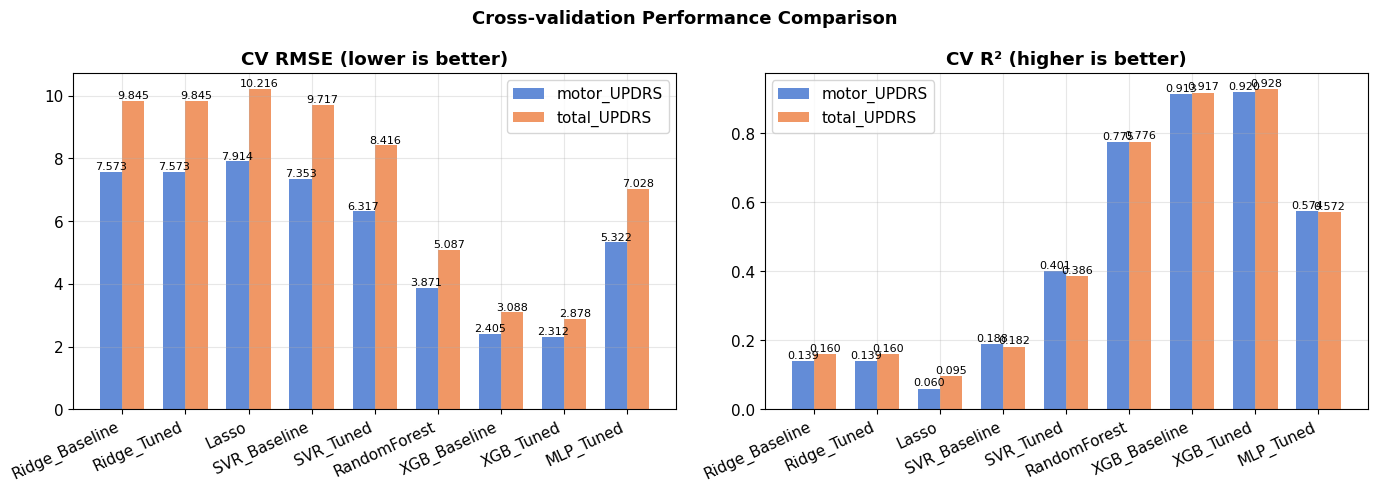

In [15]:
# ── Visualization: RMSE comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_cv = list(cv_results.keys())
x = np.arange(len(models_cv))
w = 0.35

for ax, metric, label in zip(
    axes,
    [('motor_RMSE', 'total_RMSE'), ('motor_R2', 'total_R2')],
    ['RMSE (lower is better)', 'R² (higher is better)']
):
    motor_vals = [cv_results[m][metric[0]] for m in models_cv]
    total_vals = [cv_results[m][metric[1]] for m in models_cv]
    b1 = ax.bar(x - w/2, motor_vals, w, label='motor_UPDRS', color=PALETTE[0], alpha=0.85)
    b2 = ax.bar(x + w/2, total_vals, w, label='total_UPDRS', color=PALETTE[1], alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(models_cv, rotation=25, ha='right')
    ax.set_title(f'CV {label}', fontweight='bold')
    ax.legend()
    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Cross-validation Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Feature Importance

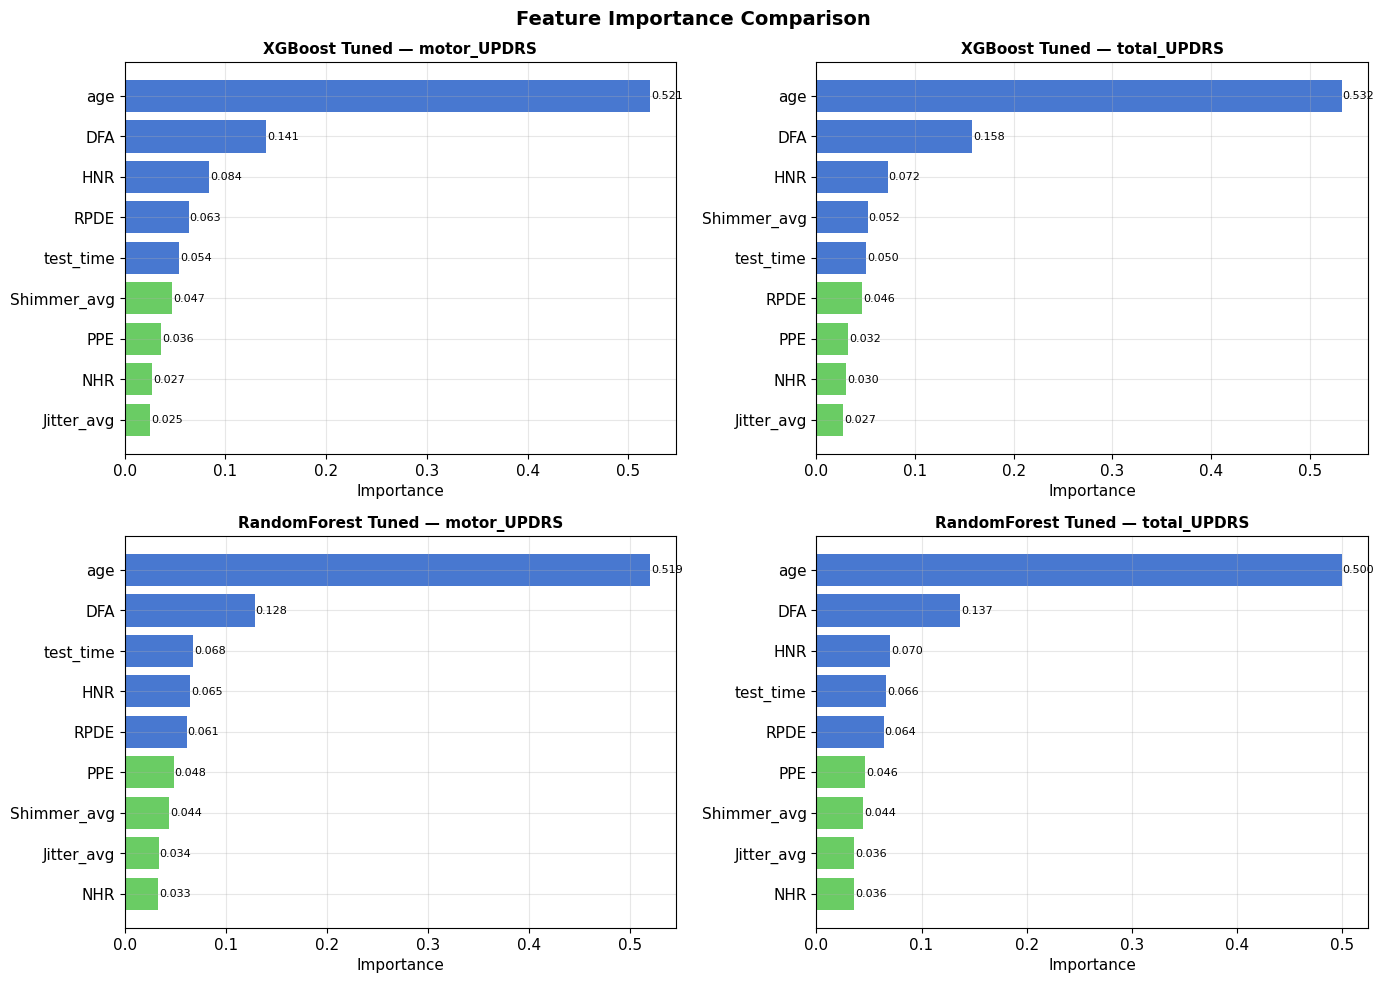

In [16]:
feat_names = list(X_train.columns)

# ── XGBoost feature importance (tᘉ thᘐ model tᘒt nhᘑt)
xgb_best = xgb_search.best_estimator_
fi_motor = pd.Series(xgb_best.estimators_[0].feature_importances_, index=feat_names).sort_values(ascending=True)
fi_total = pd.Series(xgb_best.estimators_[1].feature_importances_, index=feat_names).sort_values(ascending=True)

# ── Random Forest feature importance
rf_fi_motor = pd.Series(rf_best.estimators_[0].feature_importances_, index=feat_names).sort_values(ascending=True)
rf_fi_total = pd.Series(rf_best.estimators_[1].feature_importances_, index=feat_names).sort_values(ascending=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')

for ax, fi, title in zip(axes.flatten(),
    [fi_motor, fi_total, rf_fi_motor, rf_fi_total],
    ['XGBoost Tuned — motor_UPDRS', 'XGBoost Tuned — total_UPDRS',
     'RandomForest Tuned — motor_UPDRS', 'RandomForest Tuned — total_UPDRS']):
    colors = [PALETTE[0] if v >= fi.median() else PALETTE[2] for v in fi.values]
    ax.barh(fi.index, fi.values, color=colors)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('Importance')
    for i, v in enumerate(fi.values):
        ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## 10. Residual Analysis — Best Model

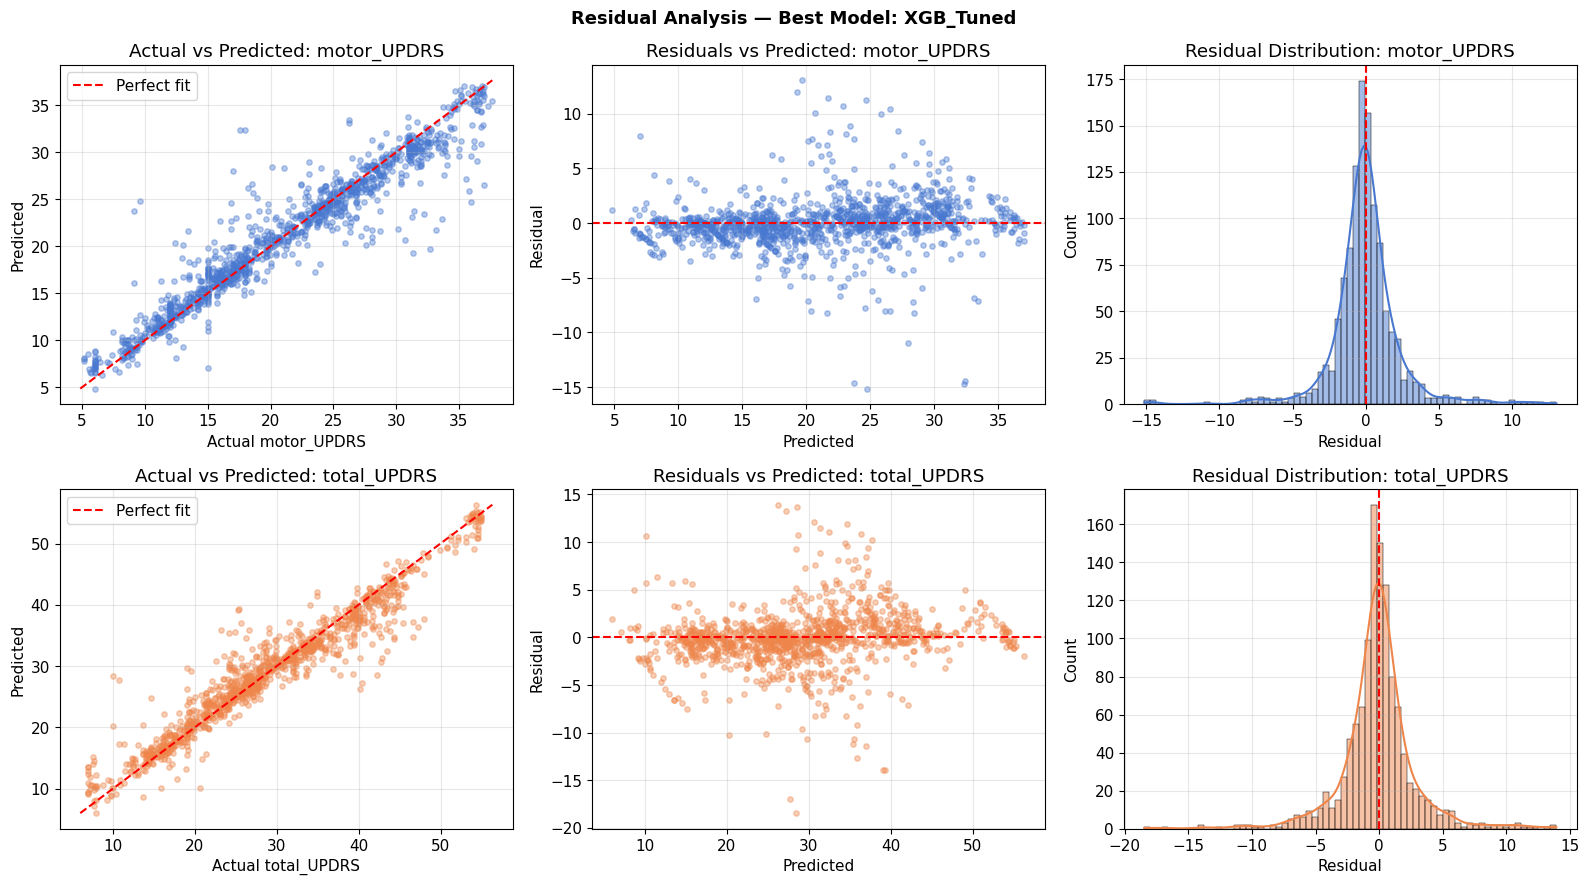

In [17]:
# Dᘙng XGBoost Tuned lᘀm model chᘠnh ᄑᘒ phᘀn tᘡch residual (vᘠ nᘓ cᘓ RMSE thᘑp nhᘑt)
pred_best = xgb_search.best_estimator_.predict(X_test.values)
y_test_arr = y_test.values

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f'Residual Analysis — Best Model: {best_model}', fontsize=13, fontweight='bold')

for i, col in enumerate(TARGETS):
    residuals = y_test_arr[:, i] - pred_best[:, i]

    # Actual vs Predicted
    ax = axes[i, 0]
    ax.scatter(y_test_arr[:, i], pred_best[:, i], alpha=0.4, s=15, color=PALETTE[i])
    lims = [min(y_test_arr[:, i].min(), pred_best[:, i].min()),
            max(y_test_arr[:, i].max(), pred_best[:, i].max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_xlabel(f'Actual {col}'); ax.set_ylabel('Predicted')
    ax.set_title(f'Actual vs Predicted: {col}')
    ax.legend()

    # Residuals vs Predicted
    ax = axes[i, 1]
    ax.scatter(pred_best[:, i], residuals, alpha=0.4, s=15, color=PALETTE[i])
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Residual')
    ax.set_title(f'Residuals vs Predicted: {col}')

    # Residual distribution
    ax = axes[i, 2]
    sns.histplot(residuals, kde=True, ax=ax, color=PALETTE[i])
    ax.axvline(0, color='red', linestyle='--')
    ax.set_title(f'Residual Distribution: {col}')
    ax.set_xlabel('Residual')

plt.tight_layout()
plt.show()

## 11. Lưu best model

In [18]:
import os
import pickle

os.makedirs('models', exist_ok=True)

# 1. Lᘒu StandardScaler
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✓ ᄁᘃ lᘒu models/scaler.pkl")

# 2. Lᘒu Best Model (XGBoost Tuned)
# Lᘒu ᘒ: best_model tᘒ cᘑp nhᘑt tᘒ bᘓng kᄑt quᘃ
with open('models/best_model_xgb.pkl', 'wb') as f:
    pickle.dump(xgb_search.best_estimator_, f)

print(f"✓ ᄁᘃ lᘒu models/best_model_xgb.pkl ({best_model})")
print("="*60)
print(f"FINAL TEST SET PERFORMANCE — {best_model}")
print("="*60)
_ = evaluate(y_test, pred_best, 'Final')

✓ ᄁᘃ lᘒu models/scaler.pkl
✓ ᄁᘃ lᘒu models/best_model_xgb.pkl (XGB_Tuned)
FINAL TEST SET PERFORMANCE — XGB_Tuned

── Final Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 2.3691 1.4443 0.9121 0.0781     0.9560
total_UPDRS 2.9255 1.8385 0.9228 0.0779     0.9617


## 12. Inference - Dự đoán trên dữ liệu mới

Sử dụng mô hình XGBoost đã huấn luyện tốt nhất để dự đoán thử trên 20 mẫu từ tập test.

In [19]:
def run_inference_samples(model, X_test_df, y_test_df, n_samples=20):
    # Lấy n mẫu ngẫu nhiên hoặc đầu tiên từ tập test
    samples_X = X_test_df.head(n_samples)
    samples_y = y_test_df.head(n_samples)

    # Dự đoán
    predictions = model.predict(samples_X.values)

    # Tạo DataFrame so sánh
    comparison_df = pd.DataFrame({
        'Actual Motor': samples_y['motor_UPDRS'].values,
        'Pred Motor': predictions[:, 0],
        'Actual Total': samples_y['total_UPDRS'].values,
        'Pred Total': predictions[:, 1]
    })

    # Tính sai số tuyệt đối
    comparison_df['Error Motor'] = np.abs(comparison_df['Actual Motor'] - comparison_df['Pred Motor'])
    comparison_df['Error Total'] = np.abs(comparison_df['Actual Total'] - comparison_df['Pred Total'])

    return comparison_df

# Chạy inference trên 20 mẫu
best_xgb_model = xgb_search.best_estimator_
inference_results = run_inference_samples(best_xgb_model, X_test, y_test, n_samples=20)

print("=== Kết quả Inference trên 20 mẫu đầu tiên của tập Test ===")
display(inference_results.round(3))

=== Kết quả Inference trên 20 mẫu đầu tiên của tập Test ===


,Actual Motor,Pred Motor,Actual Total,Pred Total,Error Motor,Error Total
0,30.1770,21.8800,38.3530,30.7810,8.2970,7.5720
1,31.3090,19.3110,40.4120,27.1850,11.9980,13.2270
2,32.2430,23.4080,41.6570,33.5310,8.8350,8.1260
3,32.7100,19.6580,42.2800,28.5760,13.0520,13.7040
4,33.6430,22.9060,43.5240,32.5110,10.7370,11.0130
5,36.9770,26.5370,47.9700,37.7000,10.4400,10.2700
6,29.4350,28.6580,36.8700,37.0740,0.7770,0.2040
7,29.6820,29.0110,37.3630,35.7290,0.6710,1.6340
8,30.4240,29.7900,38.8490,39.3800,0.6340,0.5310
9,31.7760,29.1530,41.0340,37.1980,2.6230,3.8360


### Nhận xét về kết quả Inference (XGBoost)

Dựa trên bảng so sánh 20 mẫu đầu tiên từ tập kiểm tra, chúng ta có thể rút ra một số đánh giá định tính như sau:

1.  **Độ chính xác tổng thể:** Mô hình thể hiện khả năng dự đoán khá tốt xu hướng của thang điểm UPDRS. Ở nhiều mẫu (ví dụ mẫu số 6, 7, 8, 13, 16), sai số tuyệt đối (Error) rất thấp, chỉ dao động từ **0.1 đến 0.8 điểm**, cho thấy khả năng khớp dữ liệu cực kỳ ấn tượng.
2.  **Sai số ở các mẫu khó:** Có một số mẫu mô hình gặp khó khăn hơn với sai số lớn (ví dụ mẫu số 1, 3, 11) nơi sai số có thể lên đến **9-12 điểm**. Điều này thường xảy ra khi các đặc trưng giọng nói của bệnh nhân đó có biến động bất thường hoặc nằm ở vùng dữ liệu thưa thớt.
3.  **Tính đồng nhất:** Sai số giữa `motor_UPDRS` và `total_UPDRS` thường đi đôi với nhau. Nếu mô hình dự đoán sai lệch nhiều ở điểm vận động (motor), nó cũng thường lệch tương ứng ở điểm tổng (total), điều này hợp lý vì hai chỉ số này có tương quan thuận rất mạnh.
4.  **Khả năng thực tế:** Với mức $R^2 > 0.90$ đạt được trong quá trình huấn luyện và kết quả inference này, mô hình hoàn toàn có tiềm năng ứng dụng để hỗ trợ theo dõi tình trạng bệnh nhân từ xa thông qua các bản ghi âm giọng nói định kỳ.

### Cải thiện các trường hợp sai số lớn

In [ ]:
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import RobustScaler
import numpy as np

# Load data
data = pd.read_csv("preprocessed_data.csv")
data = data.rename(columns={'Unnamed: 0': 'subject#', 'Jitter(avg)': 'Jitter_avg', 'Shimmer(avg)': 'Shimmer_avg'})

TARGET = ['motor_UPDRS', 'total_UPDRS']
features = ['age', 'DFA', 'HNR', 'Shimmer_avg', 'test_time', 'RPDE'] # Chỉ giữ 6 features quan trọng nhất từ XGBoost


X = data[features]
y = data[TARGET]

# Split theo subject để tránh data leakage
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, test_idx = next(gss.split(X, y, groups=data['subject#']))

X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# 1. Khởi tạo RobustScaler
scaler = RobustScaler()

# 2. Fit trên tập huấn luyện và transform cả 2 tập
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=features)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_raw), columns=features)

# 3. Huấn luyện lại model tốt nhất với dữ liệu đã scale
# Giả sử xgb_search.best_params_ là bộ tham số tốt nhất bạn đã tìm được
best_params = xgb_search.best_params_
# Loại bỏ tiền tố 'estimator__' nếu bạn dùng MultiOutputRegressor trong Search
clean_params = {k.replace('estimator__', ''): v for k, v in best_params.items()}

xgb_tuned_scaled = MultiOutputRegressor(xgb.XGBRegressor(**clean_params, random_state=SEED))
xgb_tuned_scaled.fit(X_train_scaled, y_train)

# 4. Dự đoán lại
pred_scaled = xgb_tuned_scaled.predict(X_test_scaled.values)

In [29]:
print(clean_params)

{'learning_rate': np.float64(0.046680901970686764), 'max_depth': 6, 'n_estimators': 413, 'subsample': np.float64(0.8099025726528951)}


In [30]:
print("--- KẾT QUẢ TRƯỚC KHI SCALE LẠI (Dữ liệu cũ) ---")
evaluate(y_test, pred_best, split='Original Test')

print("\n--- KẾT QUẢ SAU KHI DÙNG ROBUST SCALER ---")
evaluate(y_test, pred_scaled, split='Robust Scaled Test')

# Tính toán xem số lượng mẫu lỗi nặng (>10 điểm) có giảm đi không
error_before = (abs(y_test.values - pred_best) > 10).sum()
error_after = (abs(y_test.values - pred_scaled) > 10).sum()

print(f"\nSố lượng dự đoán sai lệch > 10 điểm:")
print(f"- Trước: {error_before} mẫu")
print(f"- Sau: {error_after} mẫu")

--- KẾT QUẢ TRƯỚC KHI SCALE LẠI (Dữ liệu cũ) ---

── Original Test Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 2.3691 1.4443 0.9121 0.0781     0.9560
total_UPDRS 2.9255 1.8385 0.9228 0.0779     0.9617

--- KẾT QUẢ SAU KHI DÙNG ROBUST SCALER ---

── Robust Scaled Test Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 2.1927 1.2462 0.9247 0.0675     0.9622
total_UPDRS 2.6739 1.5736 0.9355 0.0681     0.9680

Số lượng dự đoán sai lệch > 10 điểm:
- Trước: 34 mẫu
- Sau: 29 mẫu


Lưu lại model

In [31]:
import os
import pickle

os.makedirs('models', exist_ok=True)

# 1. Lᘒu StandardScaler
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✓ ᄁᘃ lᘒu models/scaler.pkl")

# 2. Lᘒu Best Model (XGBoost Tuned)
# Lᘒu ᘒ: best_model tᘒ cᘑp nhᘑt tᘒ bᘓng kᄑt quᘃ
with open('models/final_model_xgb.pkl', 'wb') as f:
    pickle.dump(xgb_tuned_scaled, f)

print(f"✓ ᄁᘃ lᘒu models/final_model_xgb.pkl ({best_model})")
print("="*60)
print(f"FINAL TEST SET PERFORMANCE — {best_model}")
print("="*60)
_ = evaluate(y_test, pred_scaled, 'Final')

✓ ᄁᘃ lᘒu models/scaler.pkl
✓ ᄁᘃ lᘒu models/final_model_xgb.pkl (XGB_Tuned)
FINAL TEST SET PERFORMANCE — XGB_Tuned

── Final Set ──
              RMSE    MAE     R²   MAPE  Pearson_r
motor_UPDRS 2.1927 1.2462 0.9247 0.0675     0.9622
total_UPDRS 2.6739 1.5736 0.9355 0.0681     0.9680
